## Fruit and Veg Classification - CNN

This project aims to develop a Convolutional Neural Network (CNN) model for fruit and vegetable classification. In the field of image processing, deep learning techniques, especially CNNs, are extremely effective in object recognition and classification tasks. In this project, a dataset was used to train the model to distinguish fruits and vegetables. The developed model has the ability to recognize various types of fruits and vegetables and has the potential to be used in applications such as automatic product recognition and quality control in the agricultural sector.

The dataset used in this project includes images of different types of fruits and vegetables. The dataset is organized to include a sufficient number of examples for each class and is divided into training, validation and test sets to increase the overall performance of the model. The images were subjected to pre-processing steps to optimize the learning process of the model.

<img src='veg.jpg' width=550 >

<a href='https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition' target=_blank>You can find the data file here</a>

In [1]:
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'fruit-and-vegetable-image-recognition:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F952827%2F3173719%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240919%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240919T151909Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D54c4eb7c306310fd8aaeae994f583ac8232e867baa4d753395510a0113b9a726f6f75236cc84e1450727332d384d66f1c95459fd2a30459f0413f390e1036a2d21fb9841306af87c8cb2dbe497c0bfb5495022a4113bb467189abf88a95232db0f8c9e10d6f88d831c5de1509cca6087f217643c2fe22fefaabdf600967e616b701a564c1e283b195cd2593026035ded210bb46d582a8e072e7f96fc22e6d51ae7d662617a99c86b9260ed3e2736baa7c893f3f09267e122747f1ea5fc808e8295434af855b92a69f4ef85dfd6402f892b2e1315e40c963fc632bd9355b1366e6e8ef09387780a4effb5d05d6cc97bd219cc05253347e01c8648d0cecb4669e1'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 2130757290 bytes downloaded
Downloaded and uncompressed: fruit-and-vegetable-image-recognition
Data source import complete.


### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Input, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from IPython.display import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import save_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import warnings
warnings.filterwarnings('ignore')

### Determine the File Path

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_21.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_1.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_66.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_50.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_85.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_48.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_51.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_68.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_92.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_54.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_74.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_60.jpg
/kaggle/input/fruit-and-vegetable-image-recognition/train/corn/Image_93.jpg
/kaggle/input

In [4]:
print(os.listdir('/kaggle/input/fruit-and-vegetable-image-recognition/train/'))

['corn', 'cabbage', 'cauliflower', 'capsicum', 'cucumber', 'carrot', 'banana', 'turnip', 'kiwi', 'beetroot', 'raddish', 'grapes', 'lemon', 'potato', 'spinach', 'pear', 'sweetpotato', 'orange', 'eggplant', 'jalepeno', 'paprika', 'watermelon', 'chilli pepper', 'onion', 'tomato', 'peas', 'bell pepper', 'soy beans', 'garlic', 'lettuce', 'apple', 'mango', 'pomegranate', 'sweetcorn', 'ginger', 'pineapple']


In [5]:
print(os.listdir('/kaggle/input/fruit-and-vegetable-image-recognition/test/'))

['corn', 'cabbage', 'cauliflower', 'capsicum', 'cucumber', 'carrot', 'banana', 'turnip', 'kiwi', 'beetroot', 'raddish', 'grapes', 'lemon', 'potato', 'spinach', 'pear', 'sweetpotato', 'orange', 'eggplant', 'jalepeno', 'paprika', 'watermelon', 'chilli pepper', 'onion', 'tomato', 'peas', 'bell pepper', 'soy beans', 'garlic', 'lettuce', 'apple', 'mango', 'pomegranate', 'sweetcorn', 'ginger', 'pineapple']


In [6]:
print(os.listdir('/kaggle/input/fruit-and-vegetable-image-recognition/validation/'))

['corn', 'cabbage', 'cauliflower', 'capsicum', 'cucumber', 'carrot', 'banana', 'turnip', 'kiwi', 'beetroot', 'raddish', 'grapes', 'lemon', 'potato', 'spinach', 'pear', 'sweetpotato', 'orange', 'eggplant', 'jalepeno', 'paprika', 'watermelon', 'chilli pepper', 'onion', 'tomato', 'peas', 'bell pepper', 'soy beans', 'garlic', 'lettuce', 'apple', 'mango', 'pomegranate', 'sweetcorn', 'ginger', 'pineapple']


In [101]:
labels=['capsicum', 'sweetcorn', 'orange', 'tomato', 'turnip', 'ginger', 'raddish','pomegranate', 'pineapple',
        'jalepeno', 'apple', 'carrot', 'lettuce', 'bell pepper','eggplant', 'beetroot','kiwi', 'pear',
        'cabbage', 'cauliflower', 'paprika', 'lemon','sweetpotato', 'grapes', 'cucumber', 'corn', 'banana',
        'garlic','chilli pepper', 'watermelon', 'mango','peas', 'onion', 'potato', 'spinach', 'soy beans']

img_path='/kaggle/input/fruit-and-vegetable-image-recognition/train/'

In [102]:
print(len(labels))

36


### Reading the pictures and labels

In [103]:
img_list=[]
label_list=[]

for label in labels:
    for img_file in os.listdir(img_path+label):
            img_list.append(img_path+label+'/'+img_file)
            label_list.append(label)


In [104]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [105]:
df.head()

,img,label
0,/kaggle/input/fruit-and-vegetable-image-recogn...,capsicum
1,/kaggle/input/fruit-and-vegetable-image-recogn...,capsicum
2,/kaggle/input/fruit-and-vegetable-image-recogn...,capsicum
3,/kaggle/input/fruit-and-vegetable-image-recogn...,capsicum
4,/kaggle/input/fruit-and-vegetable-image-recogn...,capsicum


In [107]:
df.sample(5)

,img,label
560,/kaggle/input/fruit-and-vegetable-image-recogn...,raddish
540,/kaggle/input/fruit-and-vegetable-image-recogn...,raddish
2105,/kaggle/input/fruit-and-vegetable-image-recogn...,cucumber
2676,/kaggle/input/fruit-and-vegetable-image-recogn...,peas
60,/kaggle/input/fruit-and-vegetable-image-recogn...,capsicum


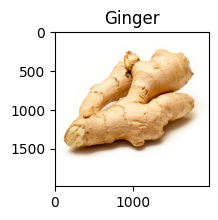

In [13]:
p='/kaggle/input/fruit-and-vegetable-image-recognition/test/ginger/Image_1.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Ginger')
plt.show()

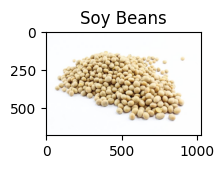

In [14]:
p='/kaggle/input/fruit-and-vegetable-image-recognition/test/soy beans/Image_4.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Soy Beans')
plt.show()

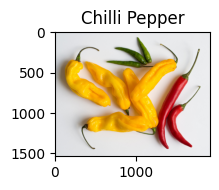

In [15]:
p='/kaggle/input/fruit-and-vegetable-image-recognition/test/chilli pepper/Image_1.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Chilli Pepper')
plt.show()

### Label Encoding

In [108]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['encoded_labels'] = le.fit_transform(df['label'])

In [109]:
df.sample(5)

,img,label,encoded_labels
2862,/kaggle/input/fruit-and-vegetable-image-recogn...,potato,27
2755,/kaggle/input/fruit-and-vegetable-image-recogn...,onion,20
2424,/kaggle/input/fruit-and-vegetable-image-recogn...,chilli pepper,8
2492,/kaggle/input/fruit-and-vegetable-image-recogn...,watermelon,35
2120,/kaggle/input/fruit-and-vegetable-image-recogn...,cucumber,10


In [110]:
x=[]

for img_path in df['img']:
    try:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (32, 32))
            img = img / 255.0
            x.append(img)
        else:
            print(f"Unable to read image: {img_path}")
    except Exception as e:
        print(f"Error processing image: {img_path}")
        print(e)

Unable to read image: /kaggle/input/fruit-and-vegetable-image-recognition/train/bell pepper/Image_56.jpg


### Modelling

In [111]:
x=np.array(x)

In [112]:
y=df['encoded_labels']

In [113]:
print(len(x))
print(len(y))

3114
3115


In [114]:
y = y[:len(x)]

In [115]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [116]:
model=Sequential()
model.add(Input(shape=(32,32,3)))
model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128))
model.add(Dense(36,activation='softmax'))
early_stopping=EarlyStopping(monitor='val_accuracy', patience=10, verbose=1)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [117]:
history=model.fit(x_train,y_train,epochs=25,verbose=1,batch_size=36,validation_data=(x_test,y_test),callbacks=[early_stopping])

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.0563 - loss: 3.5023 - val_accuracy: 0.1878 - val_loss: 2.9066
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.2170 - loss: 2.7362 - val_accuracy: 0.2697 - val_loss: 2.5730
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.3244 - loss: 2.3272 - val_accuracy: 0.2809 - val_loss: 2.4706
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4135 - loss: 2.0679 - val_accuracy: 0.2857 - val_loss: 2.5044
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.4474 - loss: 1.9248 - val_accuracy: 0.3098 - val_loss: 2.3148
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5001 - loss: 1.7002 - val_accuracy: 0.3579 - val_loss: 2.2811
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5857 - loss: 1.4279 - val_accuracy: 0.3708 - val_loss: 2.3207
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.6390 - loss: 1.2931 - val_accuracy: 0.3596 - v

In [118]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 36)                  │           4,644 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 957,230 (3.65 MB)

 Trainable params: 319,076 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 638,154 (2.43 MB)

In [119]:
loss,accuracy=model.evaluate(x_test, y_test)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3609 - loss: 4.0295
Test Loss: 3.773510456085205
Test Accuracy: 0.36276084184646606


In [120]:
pred=model.predict(x_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [121]:
confusion_matrix(y_test,np.argmax(pred,axis=1))

array([[ 1,  0,  1, ...,  1,  0,  1],
       [ 0,  8,  0, ...,  0,  0,  0],
       [ 1,  0,  8, ...,  0,  2,  0],
       ...,
       [ 1,  0,  0, ..., 10,  1,  0],
       [ 0,  1,  2, ...,  0,  7,  0],
       [ 1,  0,  0, ...,  1,  1,  4]])

In [122]:
print(classification_report(y_test, np.argmax(pred,axis=1)))

              precision    recall  f1-score   support

           0       0.07      0.09      0.08        11
           1       0.38      0.57      0.46        14
           2       0.40      0.50      0.44        16
           3       0.00      0.00      0.00        15
           4       0.41      0.39      0.40        18
           5       0.23      0.12      0.16        24
           6       0.56      0.64      0.60        14
           7       0.80      0.53      0.64        15
           8       0.33      0.24      0.28        17
           9       0.14      0.12      0.13        16
          10       0.38      0.53      0.44        15
          11       0.67      0.31      0.42        26
          12       0.73      0.47      0.57        17
          13       0.46      0.38      0.41        16
          14       0.44      0.47      0.46        17
          15       0.32      0.35      0.33        17
          16       0.67      0.44      0.53        18
          17       0.27    

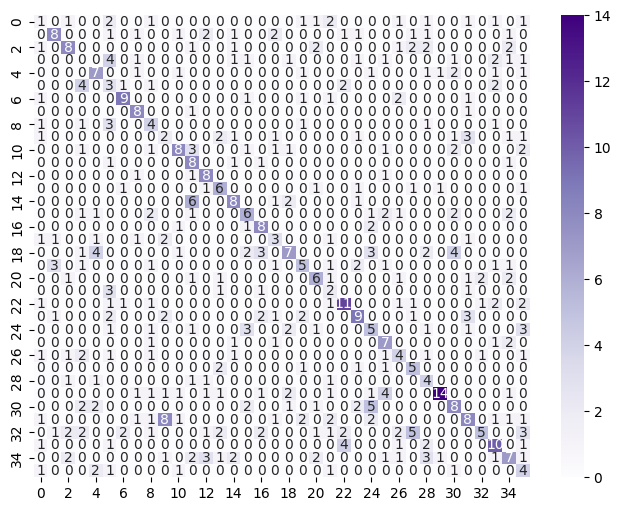

In [123]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(np.argmax(pred,axis=1), y_test)
#normalized_cm=cm / cm.sum()
sns.heatmap(cm, annot=True, cmap='Purples',annot_kws={"size": 10});

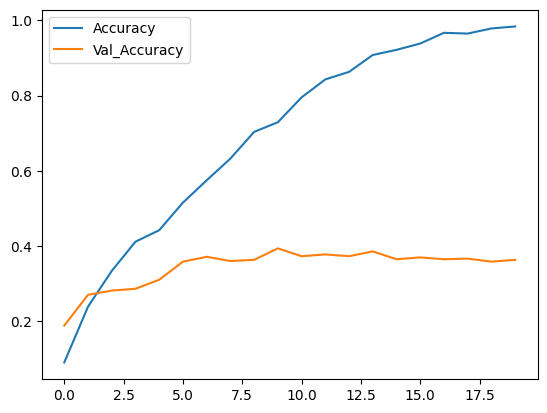

In [124]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.legend()

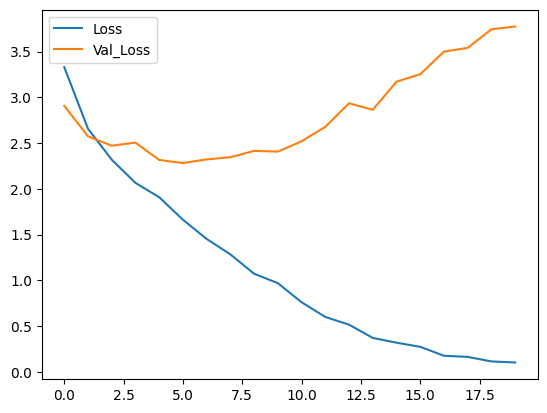

In [125]:
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['val_loss'],label='Val_Loss')
plt.legend();

In [126]:
model.save('fruit_model.h5')

## Transfer Learning

In [129]:
data_dir='/kaggle/input/fruit-and-vegetable-image-recognition/train'
test_dir='/kaggle/input/fruit-and-vegetable-image-recognition/test'

img_width,img_height=32,32
train_datagen=ImageDataGenerator(rescale=1/255,validation_split=.20)
train_datagenerator=train_datagen.flow_from_directory(directory=data_dir,target_size=(img_width,img_height),class_mode='categorical', subset='training')

test_datagen=ImageDataGenerator(rescale=1/255)
test_datagenerator=train_datagen.flow_from_directory(directory=test_dir,target_size=(img_width,img_height),class_mode='categorical', subset='validation')

base_model=VGG16(weights='imagenet', input_shape=(img_width,img_height,3),include_top=False)

model=Sequential()

model.add(base_model)
for layer in base_model.layers:
    layer.trainable=False

model.add(Flatten())
model.add(Dense(1024,activation='relu'))
model.add(Dense(36,activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train_datagenerator,epochs=15,validation_data=test_datagenerator)

Found 2510 images belonging to 36 classes.
Found 71 images belonging to 36 classes.
Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.1146 - loss: 3.3654 - val_accuracy: 0.4225 - val_loss: 2.1804
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.3473 - loss: 2.3673 - val_accuracy: 0.5493 - val_loss: 1.7735
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.4310 - loss: 1.9942 - val_accuracy: 0.5634 - val_loss: 1.5925
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.4841 - loss: 1.7872 - val_accuracy: 0.5775 - val_loss: 1.3757
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.5519 - loss: 1.5901 - val_accuracy: 0.7042 - val_loss: 1.2549
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.6106 - loss: 1.3886 - val_accuracy: 0.6479 - val_loss: 1.1501
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.6573 - loss: 1.2572 - val_accuracy: 0.6197 - val_loss: 1.0739
Epoch 8/15
79/79 ━━━━━━━━━━━━━

In [130]:
test_loss, test_acc=model.evaluate(test_datagenerator, verbose=2)
print('Test Accuracy:', test_acc)
print('Test Loss:', test_loss)

3/3 - 3s - 1s/step - accuracy: 0.8732 - loss: 0.6062
Test Accuracy: 0.8732394576072693
Test Loss: 0.6061967015266418


In [131]:
model.save('fruit.keras')

### Predict the Images

In [67]:
img=image.load_img('/kaggle/input/fruit-and-vegetable-image-recognition/test/pomegranate/Image_7.jpg', target_size=(224,224))
img=image.img_to_array(img)
img=np.expand_dims(img, axis=0)

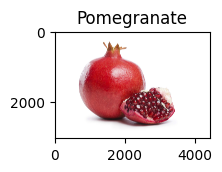

In [93]:
p='/kaggle/input/fruit-and-vegetable-image-recognition/test/pomegranate/Image_7.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Pomegranate')
plt.show()

In [68]:
model=VGG16(weights='imagenet')

In [69]:
pred=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step


In [70]:
decode_predictions(pred, top=1)

[[('n07768694', 'pomegranate', 0.63637877)]]

In [89]:
img=image.load_img('/kaggle/input/fruit-and-vegetable-image-recognition/validation/cabbage/Image_2.jpg', target_size=(224,224))
img=image.img_to_array(img)
img=np.expand_dims(img, axis=0)

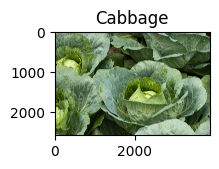

In [92]:
p='/kaggle/input/fruit-and-vegetable-image-recognition/validation/cabbage/Image_2.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Cabbage')
plt.show()

In [78]:
model=ResNet50(weights='imagenet')

In [90]:
pred=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


In [91]:
decode_predictions(pred, top=1)

[[('n07714571', 'head_cabbage', 0.8782204)]]

### Summary

In this study, a CNN model was developed for fruit and vegetable classification. The model has a multi-layered structure to learn and classify the features of images. During the training process, the overall performance of the model was increased by using data augmentation techniques. Although our success rate was slightly low when we trained our model ourselves, we eliminated this problem with transfer learning. The model correctly predicted the images we provided.

The results show that CNN-based methods are effective in image classification tasks and offer significant opportunities for automation in agricultural applications. In the future, training this model with more data and adding different types of fruits and vegetables has the potential to increase classification accuracy. In addition, studies can be done on the optimization and integration of the model for real-time applications.